In [466]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.tsa.stattools import adfuller
from scipy import stats
warnings.filterwarnings('ignore')

In [467]:
# Преобразуем "сырой" датафрейм
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result

In [468]:
# Преобразуем датафрейм для удобства работы с 2 свечными паттернами
def shift_features_2_candle(data):
    """Смещает все основные столбцы на 1 период назад

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['time', 'ticker', 'per', 'open', 'high', 'low', 'close', 'volume']

    Returns:
        data (pd.DataFrame): Новый DataFrame с преобразованными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']
    """
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    return data_c


In [469]:
# Размечаем датафрейм паттерном бычье поглощение
def detection_bullish_engulfing_pattern(data):
    """Функция для детекции бычьего паттерна поглощения

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_engulfing_pattern'
        
    """

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data


In [470]:
# Паттерн бычье харами
def detection_bullish_harami_pattern(data):
    """
    Функция для детекции бычьего паттерна 'харами' (Bullish Harami) на ценовых данныx.
    Паттерн Харами состоит из большой медвежьей свечи, за которой следует маленькая бычья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи.
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_harami_pattern'
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_harami_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие для бычьего харами
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (close_N_1 < open_N) & 
        (open_N_1 > close_N))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [471]:
# Паттерн просвет в облаках
def detection_break_in_the_clouds(data):
    """
    Свечная модель, состоящая из 2 свечей. Первая свеча падающая, 
    вторая свеча открывается ниже закрытия предыдущей и закрывается по цене, 
    которая превосходит середину предыдущей свечи.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'break_in_the_clouds'
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'break_in_the_clouds'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    center = (open_N_1 + close_N_1) / 2
    
    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N < close_N_1) & 
        (close_N < open_N_1) &
        (close_N > center))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [472]:
# Паттерн основание пинцет
def detection_base_of_tweezers(data):
    """
    Свечная модель, состоящая из 2 свечей. Первая свеча падающая, вторая свеча растущая.
    Минимумы равны, 
    которая превосходит середину предыдущей свечи.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'base_of_tweezers'
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'base_of_tweezers'
    
    # Векторизованные вычисления
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    min_N_1 = np.minimum(data['close_N-1'], data['low_N-1'])
    min_N = np.minimum(data['open_N'], data['low_N'])
    
    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (min_N == min_N_1))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [473]:
# Паттерн бычья контратака
def detection_bullish_counterattack(data):
    """
    Свечная модель, состоящая из 2 свечей. Первая свеча падающая, вторая свеча растущая.
    Цены закрытия равны или очень близки друг к другу.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_counterattack'
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_counterattack'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    

    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        ((np.abs(close_N_1 - close_N) / close_N) * 100 <= 0.05))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [474]:
# Специальная функция для проверки эффективности паттернов 
def filter_min_distance(data, column, N):
    """Некоторые паттерны расположены слишком близко друг к другу, чтобы не было наложения сделок, 
    необходимо удалить все сигналы на покупку, которые появляются во время удержания позиции.
    Время удержания N периодов

    Args:
        data (pd.DataFrame): Преобразованный датафрейм
        'signal' (int64): Сигнальный столбец.
        N (int): Количество периодов, которые мы собираемся удерживать открытую позицию

    Returns:
        data (pd.DataFrame): Исходный датафрейм с отредактированным сигнальным столбцом
    """
    data = data.copy()
    # Получаем все индексы наблюдений где у нас есть сигнал на покупку
    one_index = data[data[column] == 1].index 
    # Получаем разность между этими индексами
    distances = np.diff(one_index)
    # Маска для каждого сигнала. Первый сигнал на покупку всегда True
    mask = [True]
    
    # Перебираем все разности между индексами
    for dist in distances:
        if dist >= N:
            # Если разность между индексами больше N, то все хорошо.
            # Мы добавляем эту сделку в список
            mask.append(True)
        else:
            # Если расстояние меньше, то сделку игнорируем
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data

In [475]:
# Готовим данные для дальнейшей проверки
def data_prepare_for_statistics(data, commission=0.00025):
    """Функция предназначена для обработки результатов стратегий.

    Args:
        data (pd.DataFrame): на вход подается размеченный датафрейм с колонкой 'signal'
        commission (float, optional): Размер комисии в долях процента (0.00025 ~ 0.025%). Defaults to 0.00025.

    Returns:
        list: Возвращаем список с датафреймами, каждый датафрейм это данные по каждой сделке (дата и размер прибыли в %)
    """
    data = data.copy()
    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
    
    # Проходимся циклом по периодам удержания позиции
    all_strategy = []
    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
        data_h = data_h.set_index('time_N')
        # Блок для определения цены входа и выхода
        # То есть для каждой стратегии мы определяем вектора цен открытий и закрытий
        # Так как удерживаем позицию мы N периодов, то в качестве всех кандидатов, 
        # на которых мы можем закрыть позицию берем цены открытия через N периодов
        exit_candidate = data_h['open_N'].shift(-N) 
        is_entry = data_h['signal'] == 1
        entry_price = data_h['open_N'][is_entry]
        exit_price = exit_candidate[is_entry]
        
        # Считаем результат
        gross_profit = exit_price.values - entry_price.values
        commissions = exit_price.values * commission + entry_price.values * commission
        net_profit = gross_profit - commissions
        percent_profit_net = pd.Series(np.round(net_profit / entry_price.values, 5), index=entry_price.index,
                               name='profit_percent') # % доход за сделку
        percent_profit_without_commission = pd.Series(np.round(gross_profit / entry_price.values, 5), index=entry_price.index,
                               name='gross_profit_percent') # % доход за сделку грязный
        
        strategy_data = pd.DataFrame({'profit_percent_net' : np.array(percent_profit_net), 
                                      'percent_profit_without_commission' : np.array(percent_profit_without_commission),
                                       'N' : N, 
                                       'strategy_name' : data_h['strategy'].iloc[0],
                                       'ticker' : data_h['ticker'].iloc[0],
                                       'period' : data_h['per'].iloc[0]},
                            index=percent_profit_net.index)
        all_strategy.append(strategy_data)
        
    return all_strategy

In [476]:
# Функция для получения результатов стратегии
def trade_statistics_bull(all_strategy_data):
    """Функция предназначена для агрегирования результатов стратегий по основным финансовым метрикам

    Args:
        all_strategy_data (list): Подаётся список с датафреймами, где для для каждой сделки установлено время и размер прибыли в %.

    Returns:
        data (pd.DataFrame): Возвращаем новый датафрейм со всеми необходимыми метриками для оценки стратегий.
    """
    capital = 100_000
    strategies = []
    for strategy in all_strategy_data:
        
        # Считаем основные метрики
        ticker = strategy['ticker'].iloc[0]
        strategy_name = strategy['strategy_name'].iloc[0]
        period = strategy['period'].iloc[0]
        N = strategy['N'].iloc[0]
        count_of_trades = len(np.array(strategy['profit_percent_net']))
        profit_percent_net = strategy['profit_percent_net']
        percent_profit_without_commission = strategy['percent_profit_without_commission']
        
        # Кривая капитала 
        capital_curve_net = capital * np.cumprod(1 + strategy['profit_percent_net'])
        capital_curve_without_commission = capital * np.cumprod(1 + strategy['percent_profit_without_commission'])
        
        # Профит фактор
        pr_per_net = np.array(strategy['profit_percent_net'])
        profit_factor = np.round(np.sum(pr_per_net[pr_per_net > 0]) / np.abs(np.sum(pr_per_net[pr_per_net < 0])), 3)
        
        # Общий % доход !!!
        total_per_return_r = np.array(np.cumprod(1 + strategy['profit_percent_net']))[-1]
        total_per_return = np.round((total_per_return_r - 1) * 100, 2)
        
        # Win_rate 
        win_rate = np.round(np.mean(pr_per_net > 0), 2)
        
        # R2
        X = np.array(list(range(len(capital_curve_net)))).reshape(-1, 1)
        y = np.array(capital_curve_net)
        lin = LinearRegression()
        lin.fit(X, y)
        y_pred = lin.predict(X)
        r2 = np.round(metrics.r2_score(y, y_pred), 2)
        
        # Средняя убыточная и прибыльная сделка 
        mean_profit_trade = np.round(np.mean(pr_per_net[pr_per_net > 0]), 3)
        mean_loss_trade = np.round(np.mean(pr_per_net[pr_per_net < 0]), 3)
        avg_profit_loss_ratio = np.round(mean_profit_trade / mean_loss_trade, 3)
        
        # Максимальная просадка
        cumsum_profit = np.cumsum(pr_per_net)
        cummax_profit = np.maximum.accumulate(cumsum_profit)
        max_drawdown = np.max(cummax_profit - cumsum_profit)
        
        strategies.append({
          'ticker' : ticker,
          'strategy name' : strategy_name,
          'period' : period,
          'N' : N,
          'count of trades' : count_of_trades,
          'profit factor' : profit_factor,
          'total percent return' : total_per_return,
          'R2' : r2,
          'win_rate' : win_rate,
          'mean profit (%)' : mean_profit_trade * 100,
          'mean loss (%)' : mean_loss_trade * 100,
          'profit/loss ratio' : np.round(np.abs(avg_profit_loss_ratio), 2),
          'max drawdown (%)' : np.round(max_drawdown * 100, 1),
          'capital curve net' : capital_curve_net,
          'capital curve without commission' : capital_curve_without_commission,
          'profit percent net' : profit_percent_net,
          'percent profit without commission' : percent_profit_without_commission}
          )
        
    return pd.DataFrame(strategies)

In [477]:
# Проверяем стратегии на множестве ТФ.
def backtest_strategies_multi_tf():
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    l = []
    # Перебираем все тф
    for a in [r'C:\Users\user\Desktop\AlgoTrading\data\ROSN.txt']:
        data = pd.read_csv(a)
        for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
            data_tm = good_dataframe(data, i)
            l.append(data_tm)
        
        all_strategy = []
        # Для каждого тф проверяем стратегию бычье поглощение
        for j in l:
            for func in [detection_bullish_engulfing_pattern, detection_bullish_harami_pattern, 
                        detection_break_in_the_clouds, detection_base_of_tweezers, detection_bullish_counterattack]:
                detection_data = func(shift_features_2_candle(j))
                result = data_prepare_for_statistics(detection_data)
                final_result = trade_statistics_bull(result)
                all_strategy.append(final_result)
        # Объединяем результат   
        combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

sber_result_strategies = backtest_strategies_multi_tf()
sber_result_strategies

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,win_rate,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission
0,ROSN,bullish_engulfing_pattern,5 min,1,14753,0.451,-99.93,0.61,0.31,0.1,-0.1,1.00,721.2,time_N 2009-01-12 17:25:00 100268.000000 20...,time_N 2009-01-12 17:25:00 100318.000000 20...,time_N 2009-01-12 17:25:00 0.00268 2009-01-...,time_N 2009-01-12 17:25:00 0.00318 2009-01-...
1,ROSN,bullish_engulfing_pattern,5 min,2,14753,0.530,-99.96,0.57,0.35,0.2,-0.2,1.00,778.9,time_N 2009-01-12 17:25:00 100050.000000 20...,time_N 2009-01-12 17:25:00 100100.000000 20...,time_N 2009-01-12 17:25:00 0.00050 2009-01-...,time_N 2009-01-12 17:25:00 0.00100 2009-01-...
2,ROSN,bullish_engulfing_pattern,5 min,3,14341,0.583,-99.96,0.56,0.38,0.2,-0.2,1.00,774.8,time_N 2009-01-12 17:25:00 100000.000000 20...,time_N 2009-01-12 17:25:00 100050.000000 20...,time_N 2009-01-12 17:25:00 0.00000 2009-01-...,time_N 2009-01-12 17:25:00 0.00050 2009-01-...
3,ROSN,bullish_engulfing_pattern,5 min,4,13920,0.631,-99.94,0.57,0.39,0.2,-0.2,1.00,730.4,time_N 2009-01-12 17:25:00 100109.000000 20...,time_N 2009-01-12 17:25:00 100159.000000 20...,time_N 2009-01-12 17:25:00 0.00109 2009-01-...,time_N 2009-01-12 17:25:00 0.00159 2009-01-...
4,ROSN,bullish_engulfing_pattern,5 min,5,13469,0.651,-99.94,0.57,0.40,0.3,-0.3,1.00,727.1,time_N 2009-01-12 17:25:00 99599.000000 200...,time_N 2009-01-12 17:25:00 99649.000000 200...,time_N 2009-01-12 17:25:00 -0.00401 2009-01-...,time_N 2009-01-12 17:25:00 -0.00351 2009-01-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,ROSN,bullish_counterattack,D,30,22,0.444,-50.92,0.78,0.50,4.4,-10.0,0.44,50.1,time_N 2010-06-08 83414.000000 2011-07-14 ...,time_N 2010-06-08 83459.000000 2011-07-14 ...,time_N 2010-06-08 -0.16586 2011-07-14 -0.1...,time_N 2010-06-08 -0.16541 2011-07-14 -0.1...
626,ROSN,bullish_counterattack,D,35,20,0.632,-35.17,0.80,0.45,6.3,-8.1,0.78,42.1,time_N 2010-06-08 94028.000000 2011-07-14 ...,time_N 2010-06-08 94077.000000 2011-07-14 ...,time_N 2010-06-08 -0.05972 2011-07-14 -0.0...,time_N 2010-06-08 -0.05923 2011-07-14 -0.0...
627,ROSN,bullish_counterattack,D,40,20,0.774,-26.06,0.68,0.50,6.6,-8.6,0.77,40.0,time_N 2010-06-08 93199.000000 2011-07-14 ...,time_N 2010-06-08 93248.000000 2011-07-14 ...,time_N 2010-06-08 -0.06801 2011-07-14 -0.0...,time_N 2010-06-08 -0.06752 2011-07-14 -0.0...
628,ROSN,bullish_counterattack,D,45,20,0.812,-23.80,0.48,0.45,7.6,-7.7,0.99,42.3,time_N 2010-06-08 91497.000000 2011-07-14 ...,time_N 2010-06-08 91545.000000 2011-07-14 ...,time_N 2010-06-08 -0.08503 2011-07-14 -0.0...,time_N 2010-06-08 -0.08455 2011-07-14 -0.0...


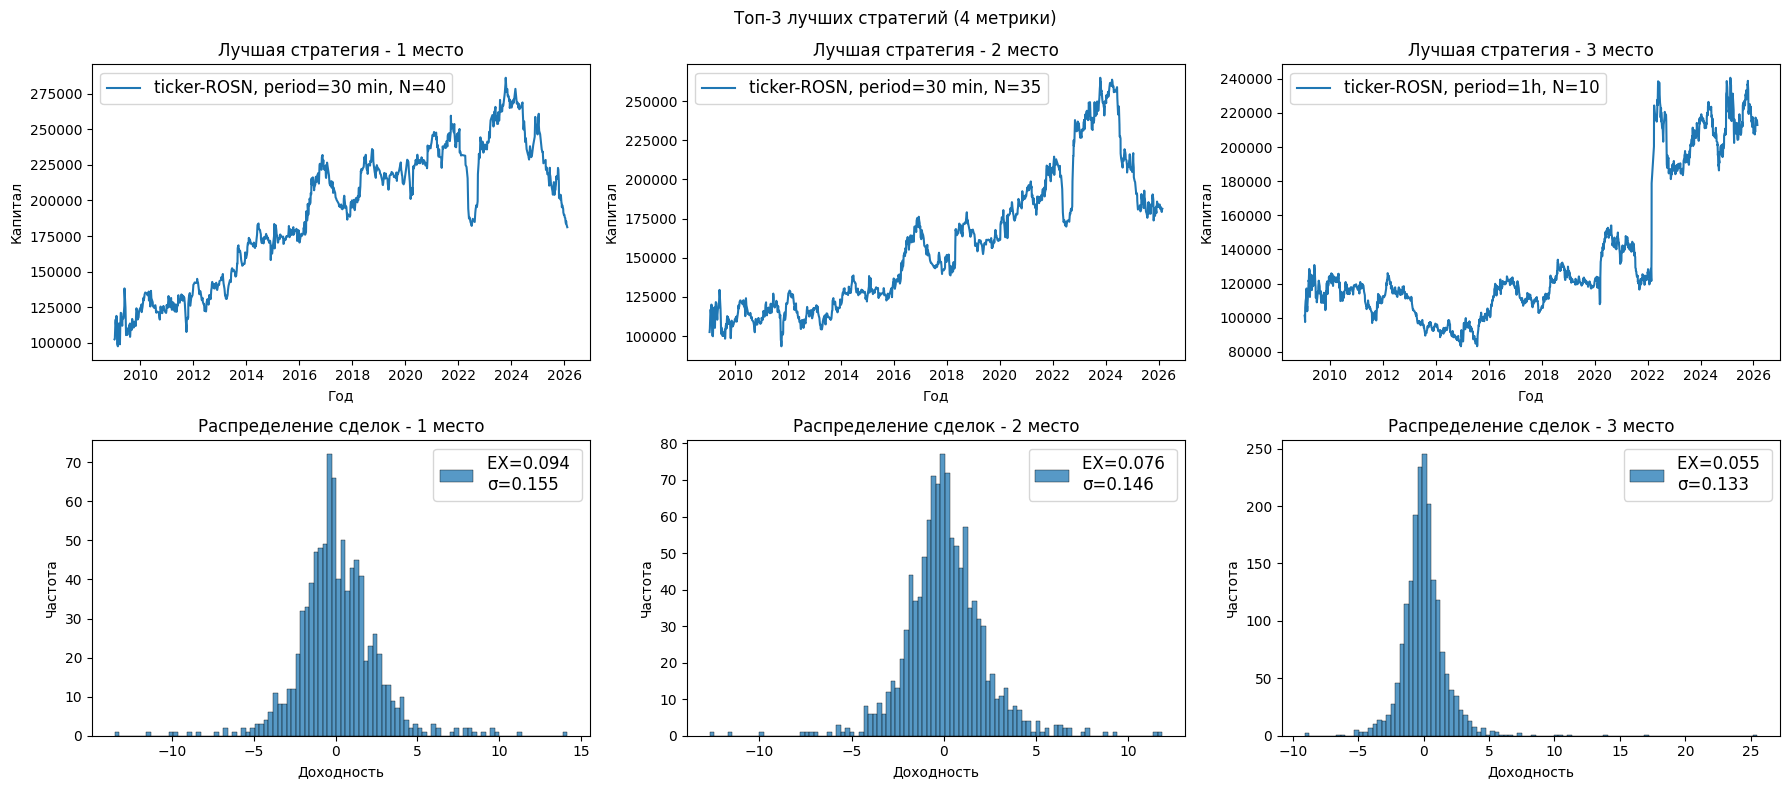

,ticker,strategy name,period,N,count of trades,profit factor,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),total percent return,R2,win_rate
0,ROSN,bullish_harami_pattern,30 min,40,917,1.117,1.9,-1.5,1.27,43.7,81.22,0.81,0.48
1,ROSN,bullish_harami_pattern,30 min,35,1121,1.105,1.6,-1.4,1.14,39.9,81.34,0.78,0.50
2,ROSN,bullish_harami_pattern,1h,10,1901,1.102,1.2,-1.0,1.20,39.6,112.94,0.67,0.49
3,ROSN,break_in_the_clouds,15 min,35,2058,1.111,1.1,-1.0,1.10,50.5,140.05,0.62,0.50
4,ROSN,bullish_harami_pattern,2h,10,1063,1.139,1.7,-1.6,1.06,60.1,126.52,0.63,0.51
5,ROSN,bullish_harami_pattern,30 min,30,1409,1.077,1.5,-1.4,1.07,54.9,57.14,0.65,0.51


In [482]:
# Функция для первичного отбора стратегий
def compare_strategies(data):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
    Returns:
        data (pd.DaraFrame): Возвращаем отфильтрованный датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[(data['count of trades'] > 900) & (data['profit factor'] > 1.05) & (data['R2'] > 0.5)] # Ограничение по количеству сделок
    if data.shape[0] != 0:
        data['profit factor rank'] = data['profit factor'].rank() # Больше лучше
        data['R2 rank'] = data['R2'].rank() # Больше лучше
        data['profit/loss ratio rank'] = data['profit/loss ratio'].rank() # Больше лучше
        data['max drawdown rank'] = data['max drawdown (%)'].rank(ascending=False) # Меньше лучше
        data['best model'] = data['profit factor rank'] + data['R2 rank'] + data['profit/loss ratio rank'] + data['max drawdown rank']
        
        # Построение графиков 3 лучших стратегий
        
        data.sort_values('best model', ascending=False, inplace=True, ignore_index=True)
        if data.shape[0] >= 3:    
            # График
            fig, axes = plt.subplots(2, 3, figsize=(18, 8))
            plt.suptitle('Топ-3 лучших стратегий (4 метрики)')
            
            # Первые 3 графика
            sns.lineplot(data.loc[0, 'capital curve net'], ax=axes[0, 0], label=f'ticker-{data.loc[0, 'ticker']}, period={data.loc[0, 'period']}, N={data.loc[0, 'N']}');
            sns.lineplot(data.loc[1, 'capital curve net'], ax=axes[0, 1], label=f'ticker-{data.loc[1, 'ticker']}, period={data.loc[1, 'period']}, N={data.loc[1, 'N']}');
            sns.lineplot(data.loc[2, 'capital curve net'], ax=axes[0, 2], label=f'ticker-{data.loc[2, 'ticker']}, period={data.loc[2, 'period']}, N={data.loc[2, 'N']}');
            axes[0, 0].legend(fontsize=12)
            axes[0, 1].legend(fontsize=12)
            axes[0, 2].legend(fontsize=12)
            
            axes[0, 0].set_title('Лучшая стратегия - 1 место')
            axes[0, 1].set_title('Лучшая стратегия - 2 место')
            axes[0, 2].set_title('Лучшая стратегия - 3 место')
            axes[0, 0].set_ylabel('Капитал')
            axes[0, 1].set_ylabel('Капитал')
            axes[0, 2].set_ylabel('Капитал')
            axes[0, 0].set_xlabel('Год')
            axes[0, 1].set_xlabel('Год')
            axes[0, 2].set_xlabel('Год')
            
            # Вторые 3 графика
            sns.histplot(data.loc[0, 'profit percent net'] * 100, ax=axes[1, 0], bins=100, 
                            label=f'EX={np.round(np.mean(data.loc[0, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit percent net"])),3)}');
            sns.histplot(data.loc[1, 'profit percent net'] * 100, ax=axes[1, 1], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[1, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit percent net"])),3)}');
            sns.histplot(data.loc[2, 'profit percent net'] * 100, ax=axes[1, 2], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[2, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit percent net"])),3)}');
            axes[1, 0].legend(fontsize=12)
            axes[1, 1].legend(fontsize=12)
            axes[1, 2].legend(fontsize=12)
                
            axes[1, 0].set_title('Распределение сделок - 1 место')
            axes[1, 1].set_title('Распределение сделок - 2 место')
            axes[1, 2].set_title('Распределение сделок - 3 место')
            axes[1, 0].set_ylabel('Частота')
            axes[1, 1].set_ylabel('Частота')
            axes[1, 2].set_ylabel('Частота')
            axes[1, 0].set_xlabel('Доходность')
            axes[1, 1].set_xlabel('Доходность')
            axes[1, 2].set_xlabel('Доходность')
                
            plt.tight_layout()
            plt.show()
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))       
            return data
        else:
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))
            return data  
            
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')
    
res = compare_strategies(sber_result_strategies)

ТЕСТ ВАЛЬДА‑ВОЛЬФОВИЦА ДЛЯ ОПРЕДЕЛЕНИЯ СЛУЧАЙНОСТИ В СЕРИЯХ СДЕЛОК
ПАТТЕРН СЛУЧАЕН


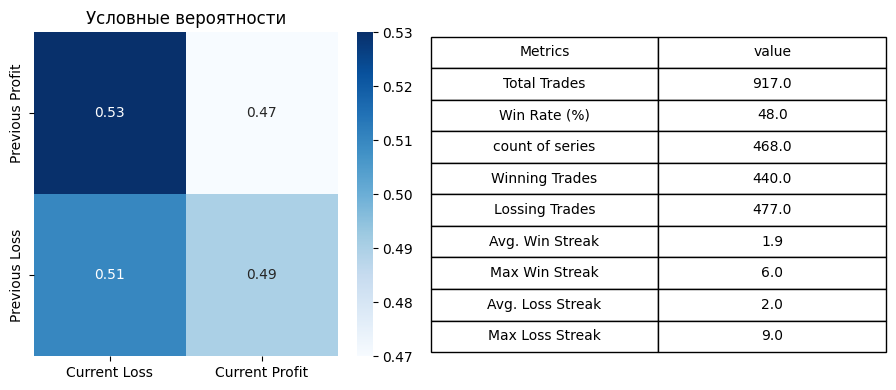

In [479]:
def run_analysis(lst):
    """Функция предназначена на статистического анализа торговой стратегии. Метрики, которые расчитываем:
    - Количество сделок всего, количество прибыльных/убыточных сделок
    - Количество серий (сколько раз был переход от прибыли к убытку и наоборот)
    - Средняя серия прибыльных/убыточных сделок
    - Максимальная серия прибыльных/убыточных сделок
    - Тест Вальда-Вольфовица для определения случайности в сериях сделок
    - Условные вероятности : P(W | W), P(W | L), P(L | W), P(L | L)

    Args:
        lst (list): Список чистых доходностей в %.

    Returns:
        Теловая карта с условными вероятностями и таблицу со всеми метриками.
    """
    if len(lst) > 0:
        lst_new = np.array(lst)
        lst_sign = (lst_new > 0).astype(int)
        n_win = np.sum(lst_sign) # Количество прибыльных сделок
        n_loss = len(lst_sign) - n_win # Количество убыточных сделок
        win_rate = np.round(n_win / len(lst_sign) * 100)
        
        # Считаем количество серий
        count_series = 1
        for i in range(1, len(lst_sign)):
            if lst_sign[i-1] != lst_sign[i]:
                count_series += 1
                
        # Считаем максимальное количество подряд идущих прибыльных сделок и среднюю серию прибыльных сделок
        list_win = []
        count_win = 0
        for i in range(len(lst_sign)):
            if lst_sign[i] == 1:
                count_win += 1
            else:
                if count_win != 0:
                    list_win.append(count_win)
                count_win = 0
        if count_win > 0:
            list_win.append(count_win) 
        
        mean_wins_series = np.round(np.mean(list_win), 1)
        max_wins_series = np.max(list_win)     
        
        # Считаем максимальное количество подряд идущих убыточных сделок и среднюю серию убыточных сделок
        list_loss = []
        count_loss = 0
        for i in range(1, len(lst_sign)):
            if lst_sign[i] == 0:
                count_loss += 1
            else:
                if count_loss != 0:
                    list_loss.append(count_loss)
                count_loss = 0
        if count_loss > 0:
            list_loss.append(count_loss)
        
        mean_loss_series = np.round(np.mean(list_loss), 1)
        max_loss_series = np.max(list_loss)
        
        
        # Проводим тест Вальда-Вольфовица для определения случайности в сериях сделок
        print('=' * 70)
        print('ТЕСТ ВАЛЬДА‑ВОЛЬФОВИЦА ДЛЯ ОПРЕДЕЛЕНИЯ СЛУЧАЙНОСТИ В СЕРИЯХ СДЕЛОК')
        print('=' * 70)
        z_stat, p_value = runstest_1samp(lst_sign, correction=False)
        if p_value < 0.05:
            print('ПАТТЕРН НЕСЛУЧАЕН')
            if z_stat < 0:
                print('Наблюдается кластеризация, серии длиннее случайных.')
            else:
                print('Частое чередование (серии короче случайных).')
        else:
            print('ПАТТЕРН СЛУЧАЕН')
            
        # Условные вероятности
        df_usl = pd.DataFrame({'current' : lst_sign})
        df_usl['previous'] = df_usl['current'].shift(1)
        df_usl.dropna(inplace=True)
        Crosstable = np.round(pd.crosstab(columns=df_usl['current'], index=df_usl['previous'], normalize='index'), 2)
        Crosstable.index = ['Previous Loss', 'Previous Profit']
        Crosstable.columns = ['Current Loss', 'Current Profit']
        
        # Таблица с метриками
        final_data = pd.Series({'Total Trades' : len(lst_sign),
                                'Win Rate (%)' : win_rate,
                                'count of series' : count_series,
                                'Winning Trades' : n_win,
                                'Lossing Trades' : n_loss,
                                'Avg. Win Streak' : mean_wins_series,
                                'Max Win Streak' : max_wins_series,
                                'Avg. Loss Streak' : mean_loss_series,
                                'Max Loss Streak' : max_loss_series}).reset_index().rename(columns={'index' : 'Metrics', 0 : 'value'})
        
        # Вывод
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
        sns.heatmap(Crosstable, annot=True, cmap="Blues", ax=ax1)
        ax1.invert_yaxis()
        ax1.set_title('Условные вероятности')
        
        
        table = ax2.table(
            cellText=final_data.values,
            colLabels=final_data.columns,
            cellLoc='center',
            loc='center')
        ax2.axis('off')
        table.scale(1.2, 1.8)
        table.auto_set_font_size(False)
        plt.tight_layout()
        plt.show()


        
        return final_data
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')


ac = run_analysis(res.loc[0, 'profit percent net'])

ТЕСТ ДИКИ-ФУЛЕРА (СТАЦИОНАРНОСТЬ)
Ряд стационарен

ТЕСТ ЛЬЮНГ-БОКСА (АВТОКОРРЕЛЯЦИЯ)
Лаг 1: Наличие автокорреляции - Нет (p > 0.05)
Лаг 2: Наличие автокорреляции - Нет (p > 0.05)
Лаг 3: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 4: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 5: Наличие автокорреляции - Да (p ≤ 0.05)

ТЕСТ НА АНДЕРСОНА-ДАРЛИНГА (НОРМАЛЬНОСТЬ)
Уровень доверия: 5.0%: Распределение Не нормальное
Уровень доверия: 2.5%: Распределение Не нормальное
Уровень доверия: 1.0%: Распределение Не нормальное

СРАВНЕНИЕ СРЕДНЕГО/МЕДИАНЫ С НУЛЁМ
МЕДИАНА: -0.076%
НЕТ оснований утверждать, что медиана значимо отличается от 0

БУСТРЕП (95%)
Средняя:   0.09%    [-0.06%, 0.25%]. Вероятность убыточности: 11.3%
Медиана:   -0.08%  [-0.2%, 0.05%]. Вероятность убыточности: 88.5%



,Normal,Without outliers
winrate (%),48.0,48.0
mean return (%),0.09,0.06
median return (%),-0.08,-0.08
profit factor,1.12,1.1
Normal dist?,NO,NO
p-value (= 0?),0.554,0.521
= 0?,YES,YES


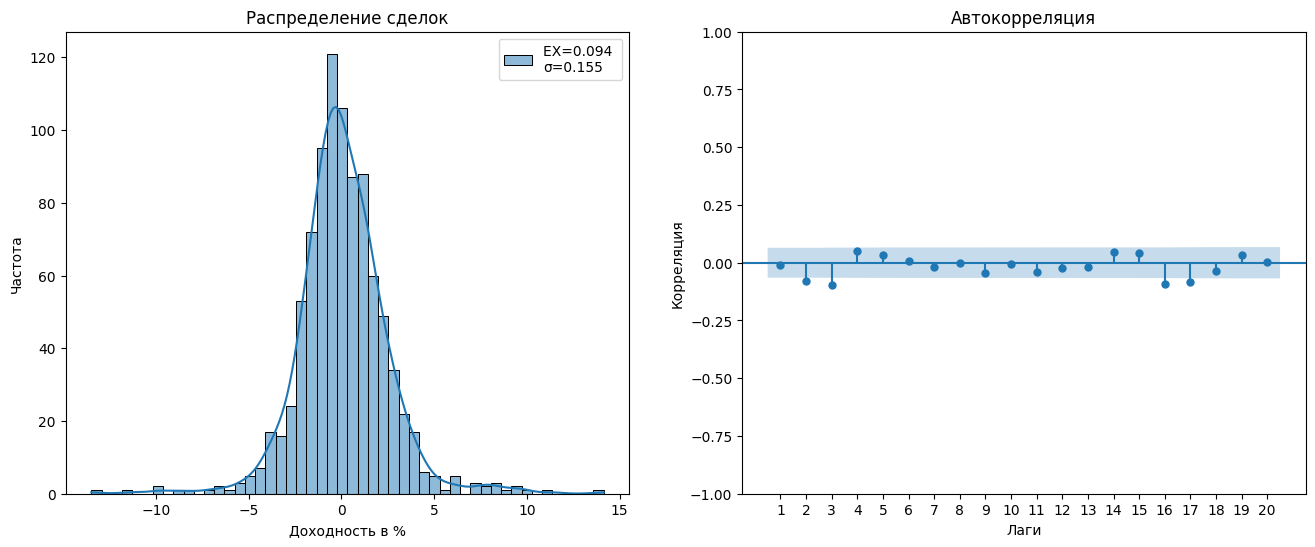

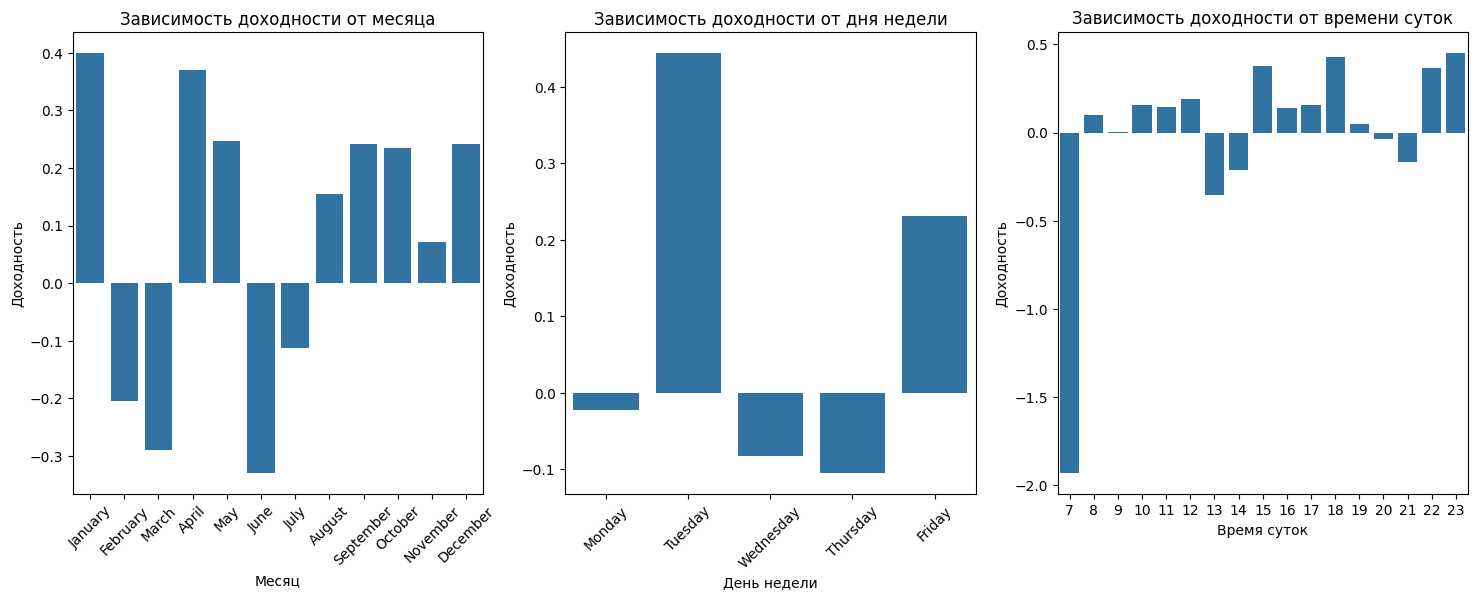

In [480]:
# Функция для глубокого статистического анализа паттернов
def deep_statistics(data, indx):
    """
    Функция предназначена для глубокого статистического анализа торговых стратегий.
    Алгоритм расчитывает:
    - График распределения доходностей и автокорреляцию
    - Проверку на стационарность
    - Проверку на автокорреляцию
    - Проверку на Нормальность
    - Сравнение средней доходности с 0
    - Анализ временных факторов на доходность

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
        indx (int): индекс стратегии
        
    """
    
    pr_percent_net = data.loc[indx, 'profit percent net']
    # 1. График
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.histplot(pr_percent_net * 100, ax=axes[0], bins=50, kde=True, 
                 label=f'EX={np.round(np.mean(pr_percent_net) * 100, 3)} \nσ={np.round(np.sqrt(np.std(pr_percent_net)),3)}')
    axes[0].set_title('Распределение сделок')
    axes[0].set_xlabel('Доходность в %')
    axes[0].set_ylabel('Частота')
    axes[0].legend(fontsize=10)
    plot_acf(pr_percent_net, zero=False, ax=axes[1], lags=20)
    axes[1].set_title('Автокорреляция')
    axes[1].set_xlabel('Лаги')
    axes[1].set_ylabel('Корреляция')
    axes[1].set_xticks(range(1, 21))
    
    # 2. Стационарность
    print('=' * 61)
    print('ТЕСТ ДИКИ-ФУЛЕРА (СТАЦИОНАРНОСТЬ)')
    print('=' * 61)
    result_adfuler = adfuller(pr_percent_net)
    if result_adfuler[1] < 0.05:
        print('Ряд стационарен')
    else:
        print('Ряд нестационарен')
    print()
    
    
    # 3. Тест Льюнг-Бокса
    print('=' * 61)
    print('ТЕСТ ЛЬЮНГ-БОКСА (АВТОКОРРЕЛЯЦИЯ)')
    print('=' * 61)
    lb_test = acorr_ljungbox(pr_percent_net, lags=np.arange(1, 6))
    for i in range(1, 6):
        print(f"Лаг {i}: Наличие автокорреляции - {'Да (p ≤ 0.05)' if lb_test.loc[i, 'lb_pvalue'] <= 0.05 else 'Нет (p > 0.05)'}")
    print()

    # 4. Нормальность распределения
    print('=' * 61)
    print('ТЕСТ НА АНДЕРСОНА-ДАРЛИНГА (НОРМАЛЬНОСТЬ)')
    print('=' * 61)
    Anderson_test = stats.anderson(pr_percent_net, dist='norm')
    for i in range(2, len(Anderson_test.significance_level)):
        sl, cv = Anderson_test.significance_level[i], Anderson_test.critical_values[i]
        print(f'Уровень доверия: {sl}%: {"Нормальное распределение" if Anderson_test.statistic < cv else "Распределение Не нормальное"}')
    print()

    # 5. Сравнение с нулевой доходностью.
    print('=' * 61)
    print('СРАВНЕНИЕ СРЕДНЕГО/МЕДИАНЫ С НУЛЁМ')
    print('=' * 61)
    if Anderson_test.statistic < Anderson_test.critical_values[2]:
        distr = 'YES'
        print(f'СРЕДНЯЯ: {np.round(np.mean(pr_percent_net) * 100, 3)}%')
        _, p_value = stats.ttest_1samp(pr_percent_net, popmean=0)
        if p_value < 0.05:
            zero = 'NO'
            print('Средняя значимо отличается от 0')
        else:
            zero = 'YES'
            print('НЕТ оснований утверждать, что средняя значимо отличается от 0')
    else:
        distr = 'NO'
        print(f'МЕДИАНА: {np.round(np.median(pr_percent_net) * 100, 3)}%')
        _, p_value = stats.wilcoxon(pr_percent_net)
        if p_value < 0.05:
            zero = 'NO'
            print('Медиана значимо отличается от 0')
        else:
            zero = 'YES'
            print('НЕТ оснований утверждать, что медиана значимо отличается от 0')
    print()
    
    # 6. Бутстреп
    print('=' * 61)
    print('БУСТРЕП (95%)')
    print('=' * 61)
    n_trades = len(pr_percent_net)
    list_mean = []
    list_median = []
    for i in range(10_000):
        sample = np.random.choice(pr_percent_net, size=n_trades, replace=True)
        median_sample = np.median(sample)
        mean_sample = np.mean(sample)
        list_median.append(median_sample)
        list_mean.append(mean_sample)
        
    mean_bootstrap = np.round(np.mean(list_mean) * 100, 2) 
    mean_lower = np.round(np.percentile(list_mean, q=2.5) * 100, 2)
    mean_upper = np.round(np.percentile(list_mean, q=97.5) * 100, 2)
    prob_mean = np.round(np.mean(np.array(list_mean) < 0) * 100, 1)
    
    median_bootstrap = np.round(np.median(list_median) * 100, 2)
    median_lower = np.round(np.percentile(list_median, q=2.5) * 100, 2)
    median_upper = np.round(np.percentile(list_median, q=97.5) * 100, 2)
    prob_median = np.round(np.mean(np.array(list_median) < 0) * 100, 1)
    print(f'Средняя:   {mean_bootstrap}%    [{mean_lower}%, {mean_upper}%]. Вероятность убыточности: {prob_mean}%')
    print(f'Медиана:   {median_bootstrap}%  [{median_lower}%, {median_upper}%]. Вероятность убыточности: {prob_median}%')
    
    # 7. Удаление 5% самых больших убытков и 5% самых больших прибылей
    five_upper = np.quantile(pr_percent_net, 0.95)
    five_lower = np.quantile(pr_percent_net, 0.05)
    pr_percent_net_blowout = pr_percent_net[(five_lower < pr_percent_net) & (pr_percent_net < five_upper)]
    # Win rate
    win_rate_n = np.round(np.mean(pr_percent_net > 0) * 100)
    win_rate_blowout = np.round(np.mean(pr_percent_net_blowout > 0) * 100)
    
    # Средние и медианы
    mean_profit_n = np.round(np.mean(pr_percent_net) * 100, 2)
    mean_profit_blowout = np.round(np.mean(pr_percent_net_blowout) * 100, 2)
    median_profit_n = np.round(np.median(pr_percent_net) * 100, 2)
    median_profit_blowout = np.round(np.median(pr_percent_net_blowout) * 100, 2)
    
    # Профит фактор
    profit_factor_n = np.round(np.sum(pr_percent_net[pr_percent_net > 0]) / np.abs(np.sum(pr_percent_net[pr_percent_net < 0])), 2)
    profit_factor_blowout = np.round(np.sum(pr_percent_net_blowout[pr_percent_net_blowout > 0]) / np.abs(np.sum(pr_percent_net_blowout[pr_percent_net_blowout < 0])), 2)
    
    # Сравнение с нулевой доходностью
    Anderson_test_blowout = stats.anderson(pr_percent_net_blowout, dist='norm')
    if Anderson_test_blowout.statistic < Anderson_test_blowout.critical_values[2]:
        distr_blowout = 'YES'
        _, p_value_b = stats.ttest_1samp(pr_percent_net_blowout, popmean=0)
        if p_value_b < 0.05:
            zero_b = 'NO'
        else:
            zero_b = 'YES'
    else:
        distr_blowout = 'NO'
        _, p_value_b = stats.wilcoxon(pr_percent_net_blowout)
        if p_value_b < 0.05:
            zero_b = 'NO'
        else:
            zero_b = 'YES'
    print()
    
    # Собираем всё вместе в табличку
    dict_normal = {'winrate (%)' : win_rate_n, 'mean return (%)' : mean_profit_n, 'median return (%)' : median_profit_n, 
                   'profit factor' : profit_factor_n,
                   'Normal dist?' : distr, 'p-value (= 0?)' : np.round(p_value, 3), '= 0?' : zero}
    dict_blowout = {'winrate (%)' : win_rate_blowout, 'mean return (%)' : mean_profit_blowout, 'median return (%)' : median_profit_blowout, 
                    'profit factor' : profit_factor_blowout,
                   'Normal dist?' : distr_blowout, 'p-value (= 0?)' : np.round(p_value_b, 3), '= 0?' : zero_b}
    df = pd.DataFrame({'Normal' : dict_normal, 'Without outliers' : dict_blowout})
    display(df)
    

    # 6 Временной анализ
    data_percent = (pr_percent_net * 100).to_frame().reset_index()
    data_percent['time_N'] = pd.to_datetime(data_percent['time_N'])
    data_percent['Month'] = data_percent['time_N'].dt.month_name()
    data_percent['day_of_week'] = data_percent['time_N'].dt.day_name()
    data_percent['hour'] = data_percent['time_N'].dt.hour
    
    # Группировка
    months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']
    weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    data_percent_group_month = data_percent.groupby('Month')['profit_percent_net'].mean().reset_index()
    data_percent_group_day_of_week = data_percent.groupby('day_of_week')['profit_percent_net'].mean().reset_index()
    data_percent_group_hour = data_percent.groupby('hour')['profit_percent_net'].mean().reset_index()
    
    # График 
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1
    sns.barplot(data_percent_group_month, x=data_percent_group_month['Month'], y=data_percent_group_month['profit_percent_net'], ax=axes[0],
                order=months)
                
    axes[0].set_title('Зависимость доходности от месяца')
    axes[0].set_xlabel('Месяц')
    axes[0].set_ylabel('Доходность')
    axes[0].set_xticklabels(labels=months, rotation=45)
    
    # 2
    sns.barplot(data_percent_group_day_of_week, x=data_percent_group_day_of_week['day_of_week'], y=data_percent_group_day_of_week['profit_percent_net'], ax=axes[1],
                order=weekdays)
    axes[1].set_title('Зависимость доходности от дня недели')
    axes[1].set_xlabel('День недели')
    axes[1].set_ylabel('Доходность')
    axes[1].set_xticklabels(labels=weekdays, rotation=45)
    
    # 3
    sns.barplot(data_percent_group_hour, x=data_percent_group_hour['hour'], y=data_percent_group_hour['profit_percent_net'], ax=axes[2])
    axes[2].set_title('Зависимость доходности от времени суток')
    axes[2].set_xlabel('Время суток')
    axes[2].set_ylabel('Доходность')

    
result_statistics = deep_statistics(res, 0)